In [1]:
import sys

# Adds src/ to the import path so `import lts` finds src/lts.py. This assumes
# the notebook's working directory is the repo root, matching the bare
# "data/..." / "coeffs_heatmap/..." paths used elsewhere in this notebook.
# If your Jupyter cwd is this examples/ folder instead, use "../src".
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
from scipy.integrate import solve_ivp
import lts

In [2]:
def print_structure(obj, name="data", indent=0):
    prefix = " " * indent

    if isinstance(obj, np.lib.npyio.NpzFile):
        print(f"{prefix}{name} (NPZ file)")
        for key in obj.files:
            print_structure(obj[key], key, indent + 2)

    elif isinstance(obj, dict):
        print(f"{prefix}{name} (dictionary)")
        for key, value in obj.items():
            print_structure(value, str(key), indent + 2)

    elif isinstance(obj, np.ndarray):
        if obj.shape == () and obj.dtype == object:
            item = obj.item()
            if isinstance(item, dict):
                print_structure(item, name, indent)
            else:
                print(f"{prefix}{name}: array, shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"{prefix}{name}: array, shape={obj.shape}, dtype={obj.dtype}")

    else:
        print(f"{prefix}{name}: {type(obj).__name__}")

In [3]:
data_path = f'../data/LORENZ_100_data.npz'
data = np.load(data_path, allow_pickle=True)
print_structure(data)

data (NPZ file)
  allow_pickle: array, shape=(), dtype=bool
  noise_0 (dictionary)
    data_0: array, shape=(101, 1001, 3), dtype=float64
    outInd_0: array, shape=(101, 0, 1), dtype=object
  noise_0.025 (dictionary)
    data_0.025: array, shape=(100, 1001, 3), dtype=float64
    outInd_0.025: array, shape=(100, 25, 1), dtype=object
    data_0.05: array, shape=(100, 1001, 3), dtype=float64
    outInd_0.05: array, shape=(100, 50, 1), dtype=object
    data_0.075: array, shape=(100, 1001, 3), dtype=float64
    outInd_0.075: array, shape=(100, 75, 1), dtype=object
    data_0.1: array, shape=(100, 1001, 3), dtype=float64
    outInd_0.1: array, shape=(100, 100, 1), dtype=object
    data_0.125: array, shape=(100, 1001, 3), dtype=float64
    outInd_0.125: array, shape=(100, 125, 1), dtype=object
    data_0.15: array, shape=(100, 1001, 3), dtype=float64
    outInd_0.15: array, shape=(100, 150, 1), dtype=object
    data_0.175: array, shape=(100, 1001, 3), dtype=float64
    outInd_0.175: array, s

In [4]:
nl = 0.1
op = 0.2

data_noisy = data[f'noise_{nl:g}'].item()[f'data_{op:g}']
ind_noisy = data[f'noise_{nl:g}'].item()[f'outInd_{op:g}']

functions = [
            lambda x: x,  # Identity function
            lambda x,y: x*y,  # Product function
        ]
function_names = [
            lambda x: f'{x}',  # Identity function
            lambda x,y: f'{x}{y}',  # Product function:
        ]

lib = ps.CustomLibrary(library_functions=functions, function_names=function_names)
lib = ps.PolynomialLibrary(degree=3)
    

In [5]:
m = data_noisy[0].shape[0]
p = int((1-op) * m)
dt = 0.1
t = np.arange(0,100+dt,dt)
rc_list = []
fr_list = []
ft_list = []
var = 2
index = np.arange(m)
for dn, true_outliers in zip(data_noisy, ind_noisy):
    b = lts.nonuni_der(dn[:,var:var+1],t)
    true_inlier = index[~np.isin(index, true_outliers)]
    D = np.array(lib.fit_transform(dn))
    xr, fr, stats, I_sorted, p = lts.ilts_search_recalc(D, dn[:,var:var+1], t, p)
    if stats == -1:
        print('outer error')
    fr_list.append(fr)
    inliers = I_sorted[:p]
    outliers = I_sorted[p:]

    tp_idx = np.isin(outliers, true_outliers)
    tn_idx = ~np.isin(inliers, true_outliers)
    fp_idx = ~tp_idx
    fn_idx = ~tn_idx

    tp = tp_idx.sum()
    tn = tn_idx.sum()
    fp = fp_idx.sum()
    fn = fn_idx.sum()

    rc = tp/(tp+fn)

    Dt = D[true_inlier]
    xt = dn[true_inlier,var:var+1]
    bt = lts.nonuni_der(xt, t[true_inlier])
    xt = np.linalg.lstsq(Dt,bt,rcond=None)[0]
    b[true_inlier] = bt
    vt =  D@xt - b
    Its = np.argsort(vt**2,axis=0).flatten()
    It = Its[:p]
    ft = np.linalg.norm(vt[It])
    ft_list.append(ft)
    rc_list.append(rc)

outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
outer error
oute

In [6]:
np.std(rc_list), np.mean(rc_list), tp, tn, fp, fn

(np.float64(0.029738695331167443),
 np.float64(0.2519),
 np.int64(49),
 np.int64(649),
 np.int64(152),
 np.int64(151))

In [7]:
ftl = np.array(ft_list)
frl = np.array(fr_list)


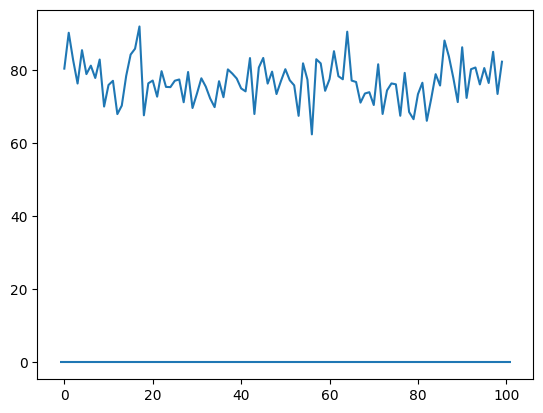

In [8]:
plt.plot(frl - ftl)
plt.hlines(0,-1,101)

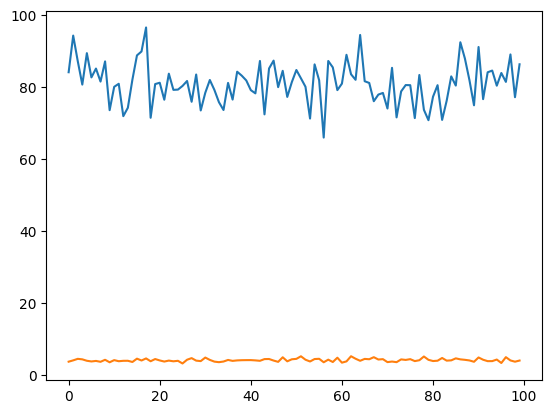

In [9]:
plt.plot(frl)
plt.plot(ftl)

In [25]:
# Solve LS
b = lts.nonuni_der(dn[:,0:1],t)
xr = np.linalg.lstsq(D,b,rcond=None)[0]
# Compute residuals
vr = D@xr - b

In [26]:
I_sorted = np.argsort(vr**2,axis=0).flatten()
Ir = I_sorted[:p] #index of the best points
print(Ir[:10])
Ir = np.sort(Ir, axis=0)
print(Ir[:10])
# print(Ir)

[573 211 574 212 572 575 210 213  41 209]
[0 1 2 3 4 5 6 7 8 9]
